In [40]:
# ============================================================
# WEBSITE TRAFFIC ANALYSIS PROJECT 
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [41]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("traffic.csv")


print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())


FIRST 5 ROWS
   event        date       country      city  \
0  click  2021-08-21  Saudi Arabia    Jeddah   
1  click  2021-08-21  Saudi Arabia    Jeddah   
2  click  2021-08-21         India  Ludhiana   
3  click  2021-08-21        France   Unknown   
4  click  2021-08-21      Maldives      Malé   

                              artist          album          track  \
0                             Tesher    Jalebi Baby    Jalebi Baby   
1                             Tesher    Jalebi Baby    Jalebi Baby   
2                      Reyanna Maria      So Pretty      So Pretty   
3  Simone & Simaria, Sebastian Yatra  No Llores Más  No Llores Más   
4                             Tesher    Jalebi Baby    Jalebi Baby   

           isrc                                linkid  
0  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
1  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
2  USUM72100871  23199824-9cf5-4b98-942a-34965c3b0cc2  
3  BRUM72003904  35573248-4e49-47c7-af80-08a960fa74c

In [42]:
# ============================================================
# DATA CLEANING
# ============================================================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Fill missing values
df.fillna("Unknown", inplace=True)

print("\nDATA AFTER CLEANING")
print(df.shape)



DATA AFTER CLEANING
(122567, 9)


In [43]:
# ============================================================
# TOTAL EVENTS / SESSIONS
# ============================================================

print("\n==============================")
print("CORE METRICS")
print("==============================")

# Total sessions/events
total_events = len(df)

print("Total Events:", total_events)

# Unique users approximation using linkid
unique_users = df['linkid'].nunique()

print("Unique Users (Link IDs):", unique_users)

# Unique countries
print("Countries:", df['country'].nunique())

# Unique cities
print("Cities:", df['city'].nunique())


CORE METRICS
Total Events: 122567
Unique Users (Link IDs): 3839
Countries: 212
Cities: 11993



EVENT DISTRIBUTION
event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


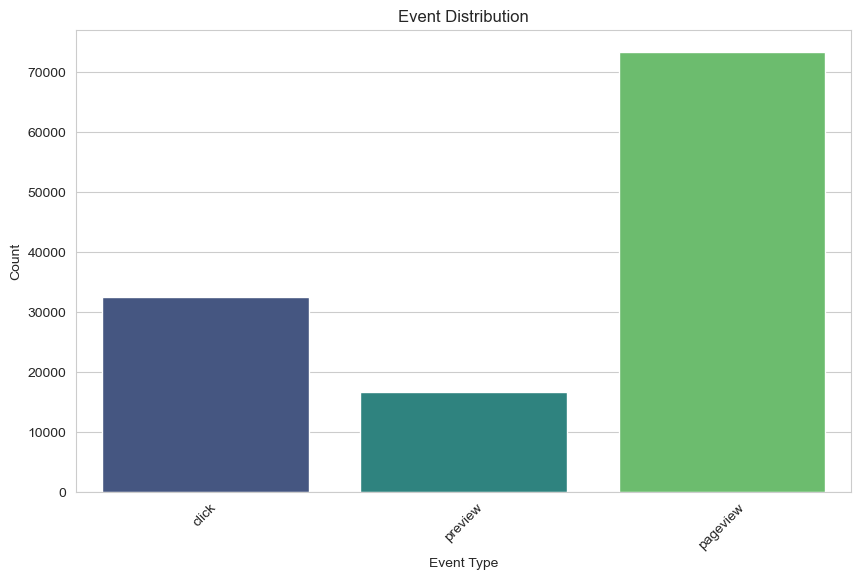

In [44]:
# ============================================================
# EVENT DISTRIBUTION
# ============================================================

print("\nEVENT DISTRIBUTION")
print(df['event'].value_counts())

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='event',
    hue='event',         
    palette='viridis',
    legend=False        
)

plt.title("Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


TOP COUNTRIES
country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
Name: count, dtype: int64


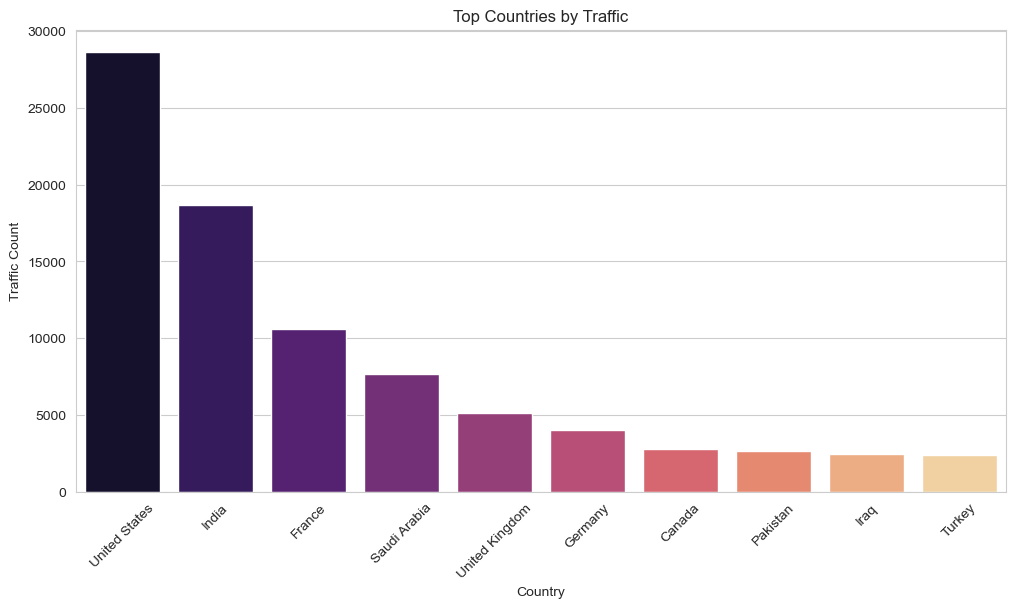

In [45]:
# ============================================================
# TOP COUNTRIES
# ============================================================

top_countries = df['country'].value_counts().head(10)

print("\nTOP COUNTRIES")
print(top_countries)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values,
    hue=top_countries.index,   
    palette='magma',
    legend=False
)

plt.title("Top Countries by Traffic")
plt.xlabel("Country")
plt.ylabel("Traffic Count")

plt.xticks(rotation=45)

plt.show()


TOP CITIES
city
Unknown        8802
Jeddah         2497
Riyadh         2232
Hyderabad      1088
Dammam         1002
Delhi           884
Jaipur          849
Lucknow         837
Kuwait City     816
Ahmedabad       808
Name: count, dtype: int64


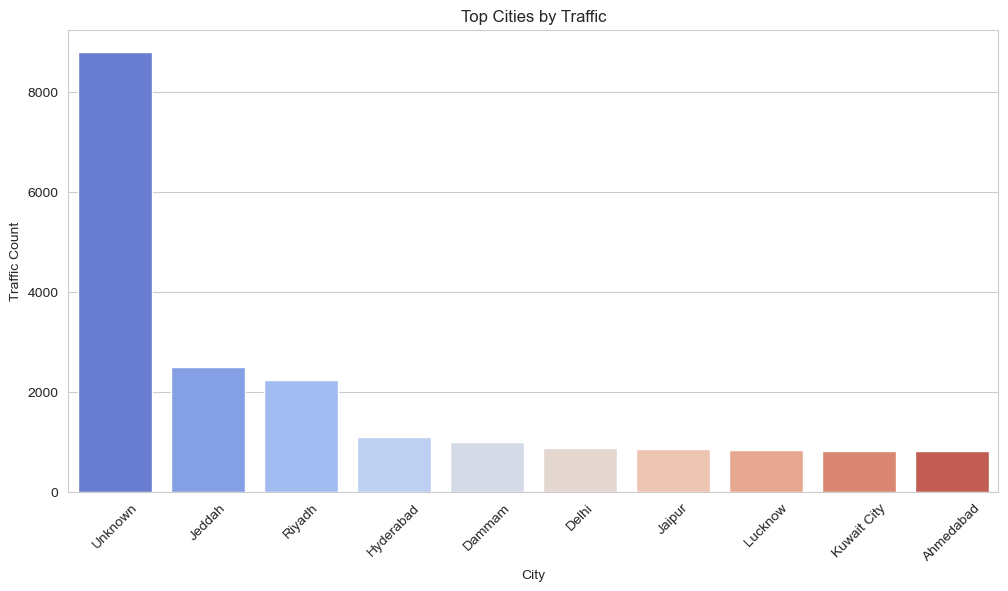

In [46]:
# ============================================================
# TOP CITIES
# ============================================================

top_cities = df['city'].value_counts().head(10)

print("\nTOP CITIES")
print(top_cities)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
    hue=top_cities.index,   
    palette='coolwarm',
    legend=False            
)

plt.title("Top Cities by Traffic")
plt.xlabel("City")
plt.ylabel("Traffic Count")

plt.xticks(rotation=45)

plt.show()


TOP ARTISTS
artist
Tesher                                                          8288
Anne-Marie                                                      4029
Tundra Beats                                                    3951
Roddy Ricch                                                     3107
Olivia Rodrigo                                                  3037
Surf Mesa, Emilee                                               2956
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2675
PinkPantheress                                                  2446
50 Cent, Olivia                                                 2390
Name: count, dtype: int64


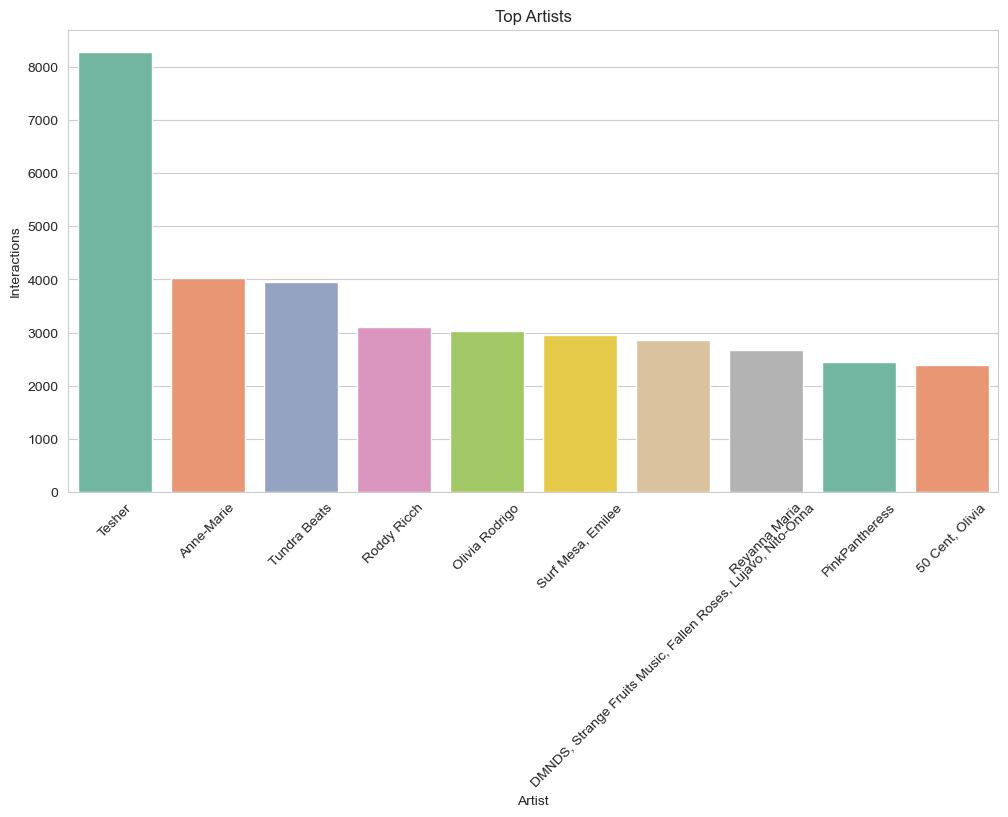

In [47]:
# ============================================================
# TOP ARTISTS
# ============================================================

top_artists = df['artist'].value_counts().head(10)

print("\nTOP ARTISTS")
print(top_artists)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_artists.index,
    y=top_artists.values,
    hue=top_artists.index,   
    palette='Set2',
    legend=False             
)

plt.title("Top Artists")
plt.xlabel("Artist")
plt.ylabel("Interactions")

plt.xticks(rotation=45)

plt.show()


TOP TRACKS
track
Jalebi Baby                              8288
Beautiful                                4037
Beautiful Day                            3951
Late At Night                            3059
ily (i love you baby) (feat. Emilee)     2956
Calabria (feat. Lujavo & Nito-Onna)      2865
So Pretty                                2830
Candy Shop                               2397
Summer of Love (Shawn Mendes & Tainy)    2108
Build a Bitch                            2072
Name: count, dtype: int64


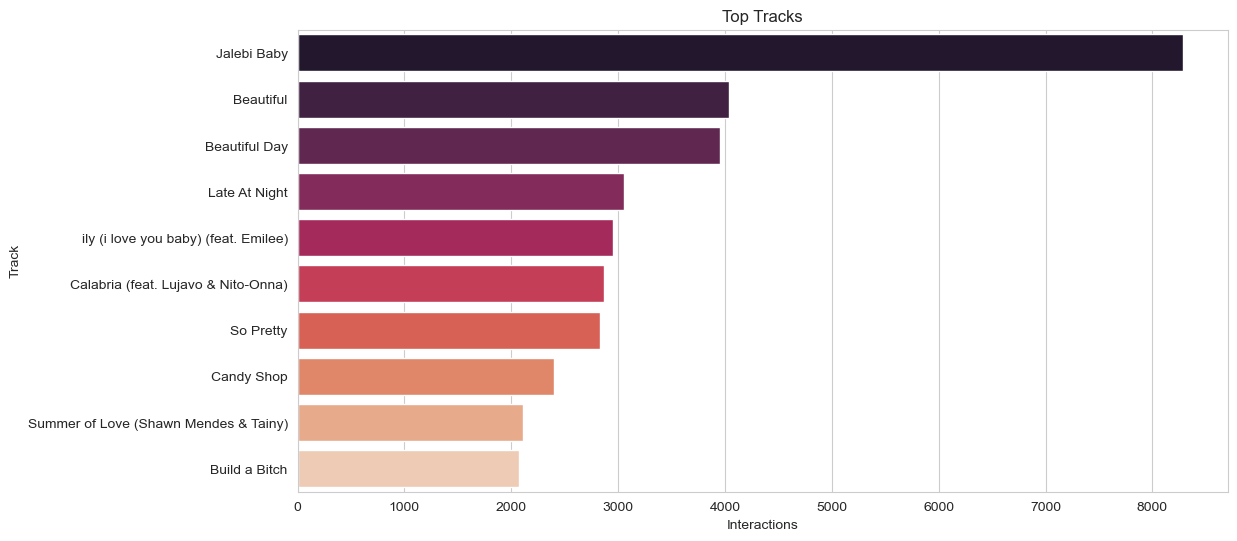

In [48]:
# ============================================================
# TOP TRACKS
# ============================================================

top_tracks = df['track'].value_counts().head(10)

print("\nTOP TRACKS")
print(top_tracks)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_tracks.values,
    y=top_tracks.index,
    hue=top_tracks.index,   
    palette='rocket',
    legend=False            
)

plt.title("Top Tracks")
plt.xlabel("Interactions")
plt.ylabel("Track")

plt.show()

In [49]:
# ============================================================
# USER JOURNEY ANALYSIS
# ============================================================

# Group user actions by linkid

user_journey = df.groupby('linkid')['event'].apply(list)

print("\nSAMPLE USER JOURNEYS")
print(user_journey.head())



SAMPLE USER JOURNEYS
linkid
00073307-ae96-5089-a117-4783afb42f8e                  [pageview, pageview]
00126b32-0c35-507b-981c-02c80d2aa8e7    [click, click, pageview, pageview]
0018cfff-50a1-5984-9715-01ef2d11a49a                            [pageview]
0033934b-5d16-5a06-af58-d087bcdd3680                            [pageview]
0034d6cf-3bd8-5ffe-aafc-b3959fc48608                            [pageview]
Name: event, dtype: object


In [50]:

# ============================================================
# EVENT TRANSITIONS
# ============================================================

transitions = []

for events in user_journey:

    if len(events) > 1:

        for i in range(len(events)-1):

            transitions.append(
                (events[i], events[i+1])
            )

# Count transitions
transition_counts = Counter(transitions)

# Convert to DataFrame
transition_df = pd.DataFrame(
    [
        (src, tgt, count)
        for (src, tgt), count
        in transition_counts.items()
    ],
    columns=['Source', 'Target', 'Count']
)

print("\nTOP EVENT TRANSITIONS")
print(
    transition_df.sort_values(
        by='Count',
        ascending=False
    ).head(10)
)


TOP EVENT TRANSITIONS
     Source    Target  Count
0  pageview  pageview  69425
1     click     click  29829
4   preview   preview  15702
2     click  pageview   1791
3     click   preview    877
5   preview  pageview    591
7   preview     click    415
6  pageview   preview     98


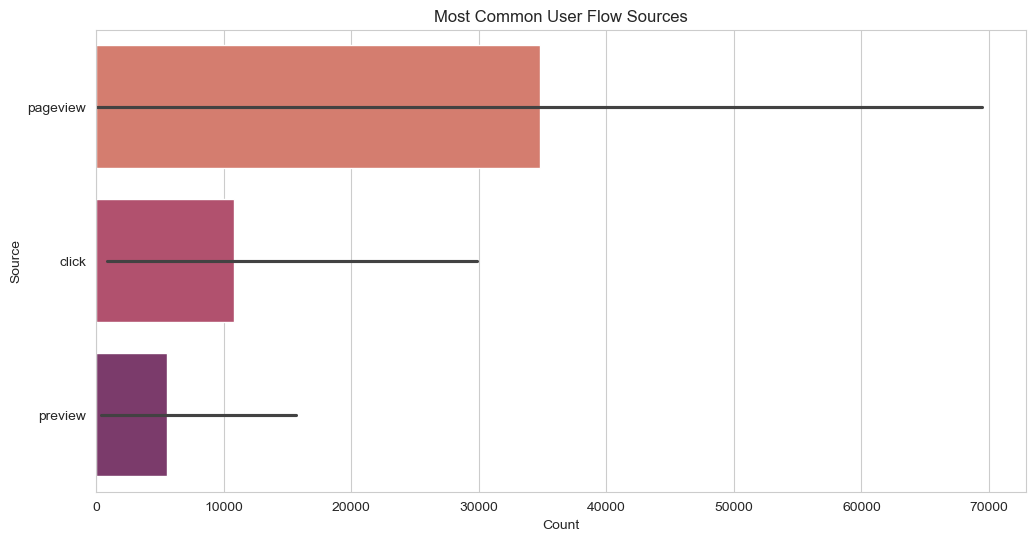

In [51]:
# ============================================================
# USER FLOW VISUALIZATION
# ============================================================

top_transitions = transition_df.sort_values(
    by='Count',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_transitions,
    x='Count',
    y='Source',
    hue='Source',      
    palette='flare',
    legend=False       
)

plt.title("Most Common User Flow Sources")

plt.show()


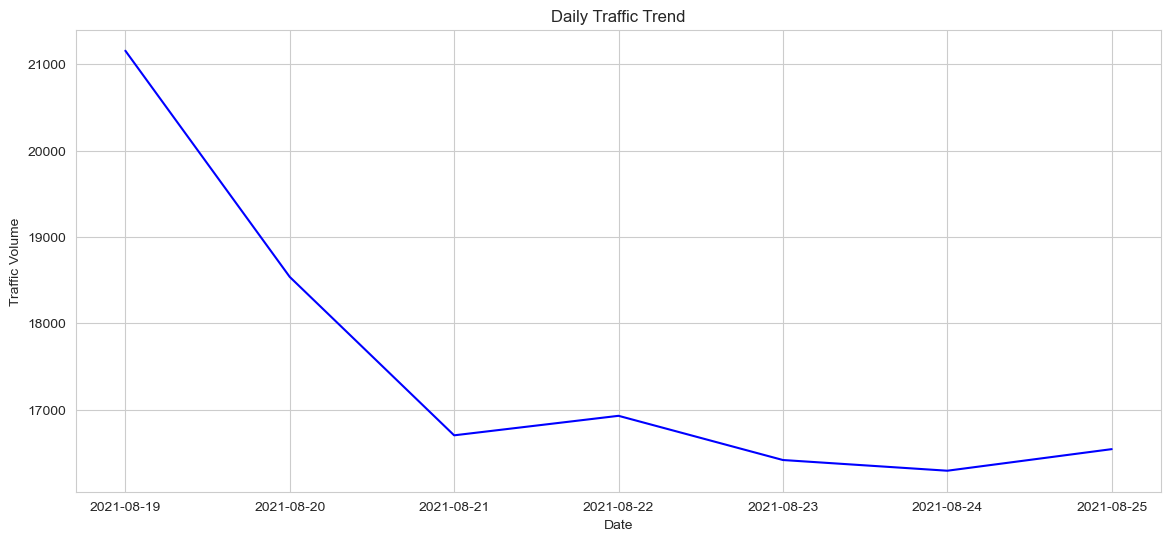

In [52]:
# ============================================================
# DAILY TRAFFIC TREND
# ============================================================

daily_traffic = df.groupby(
    df['date'].dt.date
).size()

plt.figure(figsize=(14,6))

daily_traffic.plot(color='blue')

plt.title("Daily Traffic Trend")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")

plt.show()


TOP ALBUMS
album
Jalebi Baby                             8288
Beautiful                               4028
Beautiful Day                           3950
Late At Night                           3059
ily (i love you baby) (feat. Emilee)    2956
SOUR                                    2878
The Massacre                            2870
Calabria (feat. Lujavo & Nito-Onna)     2865
So Pretty                               2830
Summer Of Love                          2108
Name: count, dtype: int64


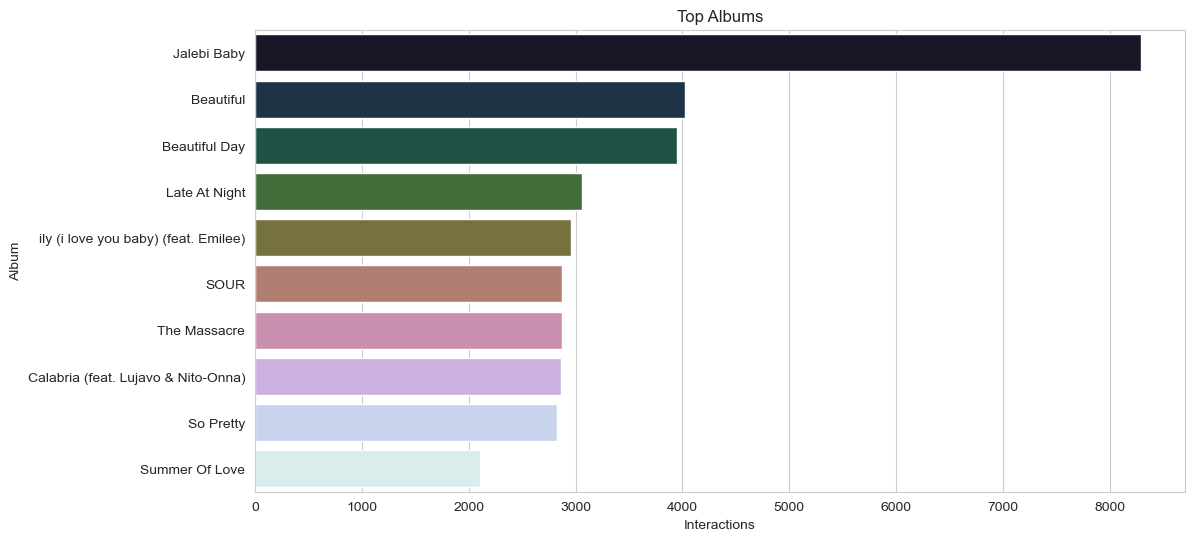

In [60]:
# ============================================================
# ALBUM POPULARITY
# ============================================================

top_albums = df['album'].value_counts().head(10)

print("\nTOP ALBUMS")
print(top_albums)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_albums.values,
    y=top_albums.index,
    hue=top_albums.index,   
    palette='cubehelix',
    legend=False           
)

plt.title("Top Albums")
plt.xlabel("Interactions")
plt.ylabel("Album")

plt.show()

In [61]:
# ============================================================
# TRACK POPULARITY BY COUNTRY
# ============================================================

country_track = df.groupby(
    ['country', 'track']
).size().reset_index(name='count')

top_country_track = country_track.sort_values(
    by='count',
    ascending=False
).head(10)

print("\nTOP TRACKS BY COUNTRY")
print(top_country_track)


TOP TRACKS BY COUNTRY
             country                                      track  count
4553           India                                Jalebi Baby   1348
3260          France                                Jalebi Baby   1014
11983  United States  Bundles 2 (feat. Flo Milli, Taylor Girlz)    993
4440           India                                  Beautiful    913
12857  United States                              Late At Night    853
4770           India       ily (i love you baby) (feat. Emilee)    781
4441           India                              Beautiful Day    778
13924  United States                                  Touchable    731
12789  United States                                Jalebi Baby    677
12430  United States                                     GYALIS    615


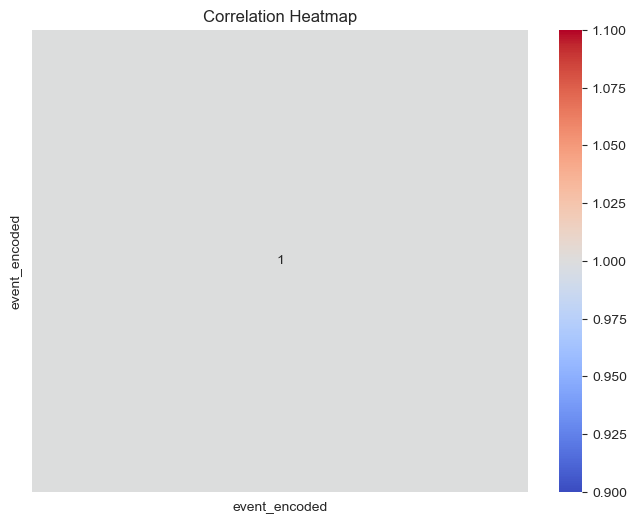

In [62]:
# ============================================================
# HEATMAP
# ============================================================

# Encode event column for correlation
df['event_encoded'] = df['event'].astype('category').cat.codes

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [63]:
# ============================================================
# ENTRY EVENTS
# ============================================================

entry_events = df.groupby('linkid').first()['event']

print("\nTOP ENTRY EVENTS")
print(entry_events.value_counts())

# ============================================================
# EXIT EVENTS
# ============================================================

exit_events = df.groupby('linkid').last()['event']

print("\nTOP EXIT EVENTS")
print(exit_events.value_counts())


TOP ENTRY EVENTS
event
click       2255
pageview    1553
preview       31
Name: count, dtype: int64

TOP EXIT EVENTS
event
pageview    3837
click          2
Name: count, dtype: int64


In [64]:
# ============================================================
# BOUNCE RATE APPROXIMATION
# ============================================================

# Bounce = users with only one event

events_per_user = df.groupby('linkid').size()

bounce_users = events_per_user[
    events_per_user == 1
]

bounce_rate = (
    len(bounce_users) / len(events_per_user)
) * 100

print("\nBOUNCE RATE")
print(round(bounce_rate, 2), "%")


BOUNCE RATE
35.56 %


In [65]:
# ============================================================
# TOP REFERRAL SOURCES APPROXIMATION
# ============================================================



top_referrals = df['country'].value_counts().head(5)

print("\nTOP TRAFFIC SOURCES (COUNTRY)")
print(top_referrals)


TOP TRAFFIC SOURCES (COUNTRY)
country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Name: count, dtype: int64


In [66]:
# ============================================================
# KEY INSIGHTS
# ============================================================

print("\n==============================")
print("KEY INSIGHTS")
print("==============================")

print("""
1. Certain events dominate user interactions.

2. A few countries and cities contribute
   most of the traffic.

3. Some artists/tracks receive significantly
   higher engagement.

4. Bounce rate indicates a portion of users
   leave after a single interaction.

5. User journey transitions reveal common
   interaction patterns.
""")
# ============================================================
# RECOMMENDATIONS FOR ALFIDO TECH
# ============================================================

print("\n==============================")
print("RECOMMENDATIONS")
print("==============================")

recommendations = [
    "1. Improve engagement for low-performing tracks/albums.",
    "2. Target high-traffic countries with localized campaigns.",
    "3. Reduce bounce rate using better landing experiences.",
    "4. Promote trending artists and tracks prominently.",
    "5. Use user journey insights for personalized recommendations."
]

for rec in recommendations:
    print(rec)


KEY INSIGHTS

1. Certain events dominate user interactions.

2. A few countries and cities contribute
   most of the traffic.

3. Some artists/tracks receive significantly
   higher engagement.

4. Bounce rate indicates a portion of users
   leave after a single interaction.

5. User journey transitions reveal common
   interaction patterns.


RECOMMENDATIONS
1. Improve engagement for low-performing tracks/albums.
2. Target high-traffic countries with localized campaigns.
3. Reduce bounce rate using better landing experiences.
4. Promote trending artists and tracks prominently.
5. Use user journey insights for personalized recommendations.
